# Feedback Loops: When a Biased Prediction Changes Tomorrow's Data

Every notebook so far in this curriculum audits a single snapshot: one dataset, one trained model, one measurement of disparity. That framing hides something important — in deployed systems, today's prediction changes what data exists to train tomorrow's model. A risk score that leads to more scrutiny of a group produces more recorded contact with that group, which can itself become "evidence" the next model is trained on.

This notebook has two parts:

1. **A real-data diagnostic** on the COMPAS dataset: `priors_count` — a major input to the COMPAS score — is itself the accumulated output of historical policing and arrest decisions, not a direct measurement of behaviour. We look at how much of the score it actually explains, and how unevenly it's distributed.
2. **A synthetic simulation** of the mechanism this implies at the population level: predictive policing's runaway feedback loop (Lum & Isaac, 2016; Ensign et al., 2018), where allocating patrol effort based on *observed* crime — rather than *true* crime, which you can only observe where you look — can lock in an extreme, self-reinforcing disparity even when the true underlying rate is identical across groups.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part 1: `priors_count` as an accumulated, non-neutral input

COMPAS's own documentation lists prior criminal history as one of the most heavily weighted inputs to its risk score. `priors_count` is not a measurement of how much crime a person has committed — it is a measurement of how many times the criminal justice system has previously recorded contact with them, which depends on enforcement intensity, charging decisions, and geography as much as on behaviour.

In [2]:
df = pd.read_csv("compas-scores-two-years.csv")
df = df[
    (df.days_b_screening_arrest <= 30)
    & (df.days_b_screening_arrest >= -30)
    & (df.is_recid != -1)
    & (df.c_charge_degree != "O")
    & (df.score_text != "N/A")
].copy()

priors_by_race = df.groupby("race", observed=True).priors_count.agg(["mean", "median", "count"]).round(2)
priors_by_race.sort_values("mean", ascending=False)

,mean,median,count
race,,,
Native American,5.18,2.0,11
African-American,4.24,2.0,3175
Caucasian,2.29,1.0,2103
Hispanic,2.10,1.0,509
Other,1.75,0.0,343
Asian,1.35,0.0,31


In [3]:
corr = df.priors_count.corr(df.decile_score)
print(f"Correlation between priors_count and decile_score: {corr:.3f}")
print(f"R-squared (priors_count alone): {corr**2:.3f}")

Correlation between priors_count and decile_score: 0.448
R-squared (priors_count alone): 0.201


`priors_count` alone explains roughly a fifth of the variance in the decile score — substantial for a single input among many, and enough that a group with systematically higher prior-arrest counts will carry a systematically higher score for that reason alone, independent of any difference in future behaviour.

**The feedback mechanism, made concrete:**

$$\text{more system contact} \;\rightarrow\; \text{more recorded priors} \;\rightarrow\; \text{higher COMPAS score} \;\rightarrow\; \text{more scrutiny / less lenient outcomes} \;\rightarrow\; \text{higher chance of further system contact}$$

This operates at two levels simultaneously:

- **Within an individual's history**: each arrest can increase the score computed at the next screening, independent of whether the underlying behaviour actually changed.
- **Across a population subgroup**: a group that has historically been arrested more often for a given true rate of offending (documented extensively in the criminology literature on differential enforcement) will show elevated `priors_count`, and therefore elevated scores, that partly reflect that enforcement history rather than the group's true underlying risk.

There is also a subtler measurement problem underneath all of this: `two_year_recid`, the outcome every notebook in this repository treats as ground truth, is itself measured via **rearrest** — meaning it inherits the same enforcement-intensity dependence as `priors_count`. Someone who reoffends but isn't caught is coded as a non-reoffender; someone who is *more heavily surveilled* is more likely to be caught for a given true behaviour. "Recidivism" in this dataset is not a clean measurement of "did this person commit another crime" — it's a measurement of "was this person caught again", and those two things can differ systematically by group.

## Part 2: Simulating a runaway feedback loop

The mechanism above compounds within COMPAS's individual scores. The same *structure* — you only observe outcomes where you look, and where you look next depends on what you observed before — governs predictive policing at the population level. We simulate it directly.

**Setup:** two groups with an **identical true underlying rate** of the event being predicted (so any divergence we see is manufactured by the feedback loop itself, not by a real difference). Each round:

1. Patrol effort is allocated across the two groups.
2. Crime is only *observed* in proportion to how much a group was patrolled — you cannot record an arrest where no one was looking.
3. The model's belief about each group's rate is updated only where new evidence came in; a group that received (near) zero patrol generates no new evidence and its belief simply doesn't move.
4. Next round's patrol allocation concentrates on whichever group currently looks riskier.

In [4]:
def simulate(seed, initial_allocation, sharpen=3.0, alpha=0.4, rounds=80, budget=50):
    rng = np.random.default_rng(seed)
    true_rate = np.array([0.10, 0.10])          # IDENTICAL true rates for both groups
    allocation = np.array(initial_allocation, dtype=float)
    estimate = np.array([0.10, 0.10])            # model starts with an unbiased belief

    history = [allocation.copy()]
    for _ in range(rounds):
        patrols = allocation * budget
        observed_crimes = rng.poisson(true_rate * patrols)
        observed_rate = np.divide(observed_crimes, patrols, out=np.zeros(2), where=patrols > 0.5)

        # a group only updates its belief if it actually received patrol effort this round
        patrolled = patrols > 0.5
        estimate = np.where(patrolled, (1 - alpha) * estimate + alpha * observed_rate, estimate)

        # next round's allocation concentrates on the higher-estimated group (sharpened, not
        # merely proportional -- this "confidence begets more looking" step is what turns an
        # ordinary feedback loop into a runaway one)
        sharpened = estimate ** sharpen
        allocation = sharpened / sharpened.sum()
        history.append(allocation.copy())

    return np.array(history)


history = simulate(seed=0, initial_allocation=(0.52, 0.48))
print(f"Initial allocation: {history[0]}")
print(f"Allocation after 5 rounds:  {history[5]}")
print(f"Allocation after 20 rounds: {history[20]}")
print(f"Allocation after 80 rounds: {history[80]}")

Initial allocation: [0.52 0.48]
Allocation after 5 rounds:  [0.9892681 0.0107319]
Allocation after 20 rounds: [9.99495611e-01 5.04389203e-04]
Allocation after 80 rounds: [0.99876226 0.00123774]


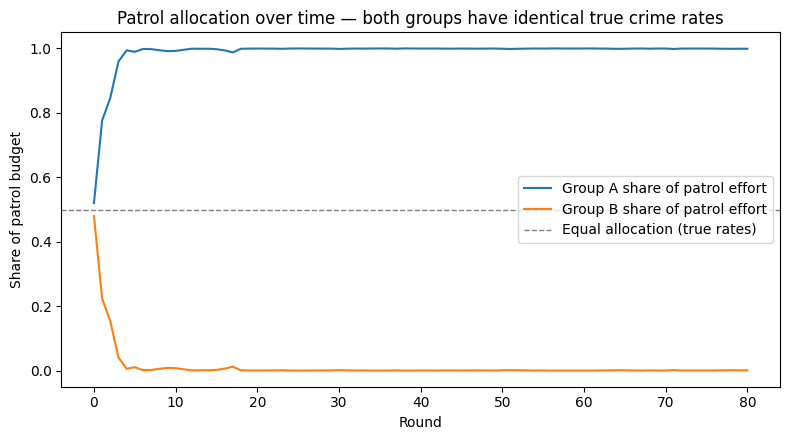

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
rounds = np.arange(len(history))
ax.plot(rounds, history[:, 0], label="Group A share of patrol effort")
ax.plot(rounds, history[:, 1], label="Group B share of patrol effort")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Equal allocation (true rates)")
ax.set_xlabel("Round")
ax.set_ylabel("Share of patrol budget")
ax.set_title("Patrol allocation over time — both groups have identical true crime rates")
ax.legend()
fig.tight_layout()
fig.show()

A 52/48 starting imbalance — smaller than the race/sex disparities we've measured in every other notebook in this curriculum — locks in to near-total concentration on one group within about five rounds, and stays there. Once a group's patrol share drops close to zero, the model stops receiving any evidence about it at all: there is no mechanism in this system that can ever discover the true rate has stayed equal, because nobody is looking anymore.

**Does the loop need an initial imbalance to run away at all?** Try starting from an exactly equal 50/50 split, across several random seeds.

In [6]:
for seed in range(5):
    h = simulate(seed=seed, initial_allocation=(0.50, 0.50))
    print(f"seed={seed}  round 20: {h[20].round(3)}   round 80: {h[80].round(3)}")

seed=0  round 20: [0.999 0.001]   round 80: [0.999 0.001]
seed=1  round 20: [1. 0.]   round 80: [0.999 0.001]
seed=2  round 20: [0.999 0.001]   round 80: [0.997 0.003]
seed=3  round 20: [0.998 0.002]   round 80: [0.978 0.022]


seed=4  round 20: [0.002 0.998]   round 80: [0.001 0.999]


Starting from perfect parity, pure sampling noise is enough: in most runs, one group or the other still gets locked out entirely within 20 rounds. No initial bias was needed — the *sharpened, evidence-starves-the-loser* structure of the feedback loop manufactures a large, persistent disparity out of nothing but randomness.

## Discussion

**Where does this show up outside the simulation?**

- **Predictive policing** (the literal setting this simulation is modelled on): patrol allocation based on historical arrest data concentrates future patrols — and therefore future recorded arrests — in already over-patrolled areas, regardless of where crime is actually occurring. This is the empirical finding in Lum & Isaac (2016) and formalised in Ensign et al. (2018).
- **COMPAS's `priors_count`**, from Part 1: the same "you only find what you look for, and what you found before determines where you look next" structure, playing out through arrest history feeding future risk scores, at both the individual and group level.
- **Content moderation, fraud detection, hiring pipelines** — anywhere a model's outputs influence which cases get reviewed, labelled, or escalated, and those labels become future training data.

**What breaks the loop?** A few real interventions, each with a real cost:

- **Forced exploration** — patrol (or review, or audit) some minimum amount everywhere, even where the model currently predicts low risk, so the system can't go permanently blind to a group. Costs resources on cases the model currently believes are low-priority.
- **Ground-truth surveys independent of enforcement** — e.g. victimisation surveys instead of arrest counts, which don't depend on where officers were already looking. Expensive and not always available.
- **Explicit caps or floors on how concentrated an allocation is allowed to become** — directly limiting the "sharpening" step. A policy choice, not a statistical fix.
- **Auditing the allocation itself over time**, not just a single model's snapshot fairness — exactly the kind of longitudinal check none of this curriculum's other notebooks perform, because they all analyse a single frozen dataset.

**Discussion questions for students:**

1. In the simulation, try lowering `sharpen` toward 1.0 (plain proportional allocation, no extra concentration) and re-run. Does the loop still run away? What does this tell you about which part of the mechanism is doing the damage — the feedback structure itself, or the "concentrate on whoever currently looks worse" decision rule layered on top of it?
2. Add a small constant "exploration floor" to the allocation each round (e.g. every group gets at least 5% of the patrol budget regardless of its estimate) and re-run. How large does the floor need to be before the loop stops locking in?
3. Connect this back to `intersectional_subgroups.ipynb`: if a small intersectional subgroup's low sample size is itself partly a product of historical under-scrutiny (rather than pure population rarity), what does that imply about trying to "fix" the sample-size problem by collecting more data from the same pipeline?